# Marlim3 - Python Tutorials

# Nodal analysis of flow

In this notebook, we will set up a steady-state base case in [Marlim3](https://github.com/petrobras/marlim3) and perform various simulations, varying some system properties, to illustrate the basic concepts of [nodal analysis](https://petrowiki.spe.org/Nodal_analysis) of flow.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import marlim3
import copy

## Introduction

One of the main activities of the flow assurance discipline is to predict the pressure drop along the fluid path, from the bottom of the well to the platform. In engineering fluid mechanics, this pressure drop is known as pressure loss. This phenomenon is directly related to flow characteristics in the pipeline, such as fluid properties, line geometry, among other factors, and can be modeled using multiphase flow simulators, such as [**Marlim3**](https://github.com/petrobras/marlim3). Since the arrival pressure at the platform is previously defined to meet the demands of the primary processing of the surface plant, the variable of interest becomes the pressure at the bottom of the well. This pressure must be sufficient to overcome the pressure loss and ensure that the specified pressure is reached at the platform.


### IPR: Inflow Performance Relationship

But what happens before the bottom of the well? The fluid comes from the oil reservoir, where the driving force for flow is the pressure differential between the reservoir pressure (known as static pressure, $P_e$) and the bottom hole pressure ($P_{wf}$). This phenomenon is modeled in the Reservoir discipline and depends on the characteristics of flow in the porous medium of the reservoir.

How, then, does the integration between the Reservoir and Flow Assurance disciplines occur for system modeling? Reservoir typically provides Flow Assurance with a curve that relates the produced flow rate to the static pressure and the bottom hole pressure. This curve, known as IPR (Inflow Performance Relationship), is used as a boundary condition in pipeline flow simulations. Also called the available pressure curve, the IPR relates the bottom hole pressure to the flow rate produced at surface conditions. It is a representation of reservoir productivity and is a function of the characteristics of the porous medium that composes it.

The simplest IPR model is the linear one:

$$Q = \texttt{IP}(P_e-P_{wf}),$$

where $Q$ is the flow rate at surface conditions, $P_e$ is the static pressure of the reservoir, and $P_{wf}$ is the bottom hole pressure.

The $\texttt{IP}$ parameter, known as the productivity index, represents the proportionality constant between the produced flow rate and the pressure differential between the reservoir and the bottom of the well. This differential is interpreted as the driving force for flow in the section in question. The linear model is particularly useful for describing single-phase flows in porous media. However, when pressure is below the saturation pressure and gas begins to be released already in the porous medium, it is recommended to adopt other models, such as the Vogel model, also available in [**Marlim3**](https://github.com/petrobras/marlim3).

### TPR: Tubing Performance Relationship

The IPR curve, provided by the RES discipline, describes the relationship between produced flow rate and pressure differential between the reservoir and the bottom of the well. Analogously, EE uses multiphase flow simulations to generate a curve called TPR (Tubing Performance Relationship), or required pressure curve, which relates the same produced flow rate to the pressure differential between the bottom of the well and the platform. The intersection point between the two curves represents the flow rate and pressure that the system will effectively produce when in equilibrium, in steady state.

This approach is known as nodal analysis, as it determines the state of the system at the intersection point of pressure curves at a specific node in the line — in this case, the bottom of the well.

In this notebook, we will explore how to perform nodal analysis using [**Marlim3**](https://github.com/petrobras/marlim3).

## Base case setup

We will populate a `Tramo` object from [**Marlim3**](https://petrobrasbr.sharepoint.com/teams/Marlim3) for the base case:

In [2]:
caso_base = marlim3.Tramo()

### Production fluid

We define a [*black oil*](https://wiki.whitson.com/bopvt/bot/) type production fluid:

In [3]:
fluido = {
    "id": 0,
    "api": 20,
    "rgo": 50,
    "densidadeGas": 0.7,
    "bsw": 0.0,
}

caso_base.fluidosProducao = [fluido]

[**Marlim3**](https://github.com/petrobras/marlim3) offers other fluid modeling possibilities: *flash* tables and compositional models.

### Formation

In [**Marlim3**](https://github.com/petrobras/marlim3), it is possible to add a list of thermal information related to rock lithology, which can be used to model heat exchanges between the well and the formation. Below, we include an example of a typical rock with one year of production time. This parameter is relevant because, as the well produces, the surrounding rock is gradually thermally influenced by the flowing fluid.

In [4]:
rocha = {
    "id": 0,
    "condutividade": 2.5, # W/(m.degC)
    "calorEspecifico": 1e3, # J/(kg.degC)
    "massaEspecifica": 2.5e3 # kg/m3
}

caso_base.configuracaoInicial['Formacao'] = {
    'Propriedades': [rocha],
    'TempoProducao': 365 #dias 
}

### Pipeline

#### Materials

Below we define two materials to be used to compose the pipeline: steel and an insulating material.

In [5]:
aco = {
    "id": 0,
    "rotulo": "Aço",
    "tipo": 0, # sólido
    "condutividade": 58, #W/m.K
    "calorEspecifico": 480, #J/kg.K
    "rho": 7850, #kg/m3
}

fluido_completacao = {
    "id": 1,
    "rotulo": "Fluido de completação",
    "tipo": 2 #água
}

cimento = {
    "id": 2,
    "rotulo": "Cimento",
    "tipo": 0, #sólido
    "condutividade":0.6,
    "calorEspecifico":1000.0,
    "rho":500.0
}

isolante = {
    "id": 3,
    "rotulo": "Isolante",
    "tipo": 0, # sólido
    "condutividade": 0.12, #W/m.K
    "calorEspecifico": 1214, #J/kg.K
    "rho": 510, #kg/m3
}

caso_base.material = [aco, fluido_completacao, cimento, isolante]

#### Cross-sections

The production system is composed of several layers that will make up the different cross-sections.

In [6]:
camada_aco_interna = {
    "rotulo": "Camada de aço interna",
    "idMaterial": 0, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*0.25, #m
}

camada_fluido_completacao = {
    "rotulo": "Camada de fluido de completação",
    "idMaterial": 1, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*3, #m
}

camada_aco_revestimento = {
    "rotulo": "Camada de aço do revestimento",
    "idMaterial": 0, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*0.5, #m
}

camada_cimento = {
    "rotulo": "Camada de cimento",
    "idMaterial": 2, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*3, #m
}

camada_isolante = {
    "rotulo": "Camada de isolante",
    "idMaterial": 3, #id do material definido anteriormente
    "tipoMedicaoCamada": "ESPESSURA",
    "espessura": 0.0254*2, #m
}

Two cross-sections are defined in the system: one corresponding to the well, composed only of the steel layer, and another referring to the flowline and riser, formed by two layers — steel and insulating material. Both sections have the same internal diameter ($8$") and the same absolute roughness ($0.183$ mm).

In [7]:
secao_poco = {
    "id": 0,
    "rotulo": "Corte do poço",
    "diametroInterno": 8*0.0254, #m
    "rugosidade": 0.183e-3, #m
    "camadas": [camada_aco_interna, camada_fluido_completacao, camada_aco_revestimento, camada_cimento]
}

secao_flowline_riser = {
    "id": 1,
    "rotulo": "Corte da flowline+riser",
    "diametroInterno": 8*0.0254, #m
    "rugosidade": 0.183e-3, #m
    "camadas": [camada_aco_interna, camada_isolante]
}

With the two sections defined, we can add them to the `secaoTransversal` attribute:

In [8]:
caso_base.secaoTransversal = [secao_poco, secao_flowline_riser]

#### Ducts

In [**Marlim3**](https://github.com/petrobras/marlim3), the pipeline is divided into sections called ducts. In this case, there will be three portions: well, flowline, and riser. Each of them will have a length of $1000$ m and will be subdivided into 10 cells for discretization.

##### Well

A typical behavior of the geothermal gradient in wells shows a more pronounced temperature decrease in the final portion. To represent this behavior, we define temperatures at three points along the relative length of the duct: $90$°C at the beginning, $50$°C at 80% of the length, and $4$°C at the end, corresponding to the seabed temperature.

In [9]:
ncel = 10

comprimento_total = 1000 #m

discretizacao = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_formacao = {
          "compInter": [0, 0.8, 1],
          "tempExterna": [90, 50, 4], #degC
}

coluna = {
        "id": 0,
        "rotulo": "Poço",
        "idCorte": 0, #id da seção transversal de poço definida anteriormente
        "idFormacao": 0, #id da formação definida anteriormente
        "angulo": np.pi/2, #rad
        "discretizacao": [discretizacao], #discretização definida logo acima
        "condicoesIniciais": condicoes_formacao #condições definidas logo acima
} 

##### Flowline

In the flowline, the external environment is specified as seawater. For this case, it is necessary to define the external temperature and external velocity:

In [10]:
ncel = 10

comprimento_total = 1000 #m

discretizacao = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_leito_marinho = {
          "compInter": [0, 1],
          "tempExterna": [4, 4], #degC
          "velExterna": [0.1, 0.1], #m/s

}

linha = {
        "id": 1,
        "rotulo": "Flowline",
        "idCorte": 1, #id da seção transversal de flowline+riser definida anteriormente
        "ambienteExterno": 1, #água do mar
        "angulo": 0, #rad
        "discretizacao": [discretizacao], #discretização definida logo acima
        "condicoesIniciais": condicoes_leito_marinho #condições definidas logo acima
}

##### Riser

In the riser, the external environment is also seawater, but this time there is a temperature and velocity gradient from the seabed to the surface:

In [11]:
ncel = 10

comprimento_total = 1000 #m

discretizacao = {
    "nCelulas": ncel,
    "comprimento": comprimento_total/ncel #m
}

condicoes_mar_subida = {
          "compInter": [0, 1],
          "tempExterna": [4, 20], #degC
          "velExterna": [0.1, 1], #m/s

}

riser = {
        "id": 2,
        "rotulo": "Riser",
        "idCorte": 1, #id da seção transversal de flowline+riser definida anteriormente
        "ambienteExterno": 1, #água do mar
        "angulo": np.pi/2, #rad
        "discretizacao": [discretizacao], #discretização definida logo acima
        "condicoesIniciais": condicoes_mar_subida #condições definidas logo acima
}

With the three ducts defined, we can add them to the `dutosProducao` attribute:

In [12]:
caso_base.dutosProducao = [coluna, linha, riser]

Visualizing the geometry:

In [13]:
caso_base.plotar_geometria();

### Master 1

To indicate the position of the Subsea Christmas Tree (ANM), a `master1` object will be defined. This object represents the valve responsible for controlling production at the ANM. In steady state, master1 has no effect beyond this indication of the ANM position, so the only property filled in will be `comprimentoMedido`:

In [14]:
master1 = {'comprimentoMedido': 1000} #m
caso_base.master1 = master1

In a transient simulation, it would be important to define the valve opening, even if it remained constant over time.

### Boundary conditions

The boundary conditions (BC) in our case are $1$) IPR upstream and $2$) pressure downstream.

#### BC1: Upstream IPR

BC $1$ must be defined through an `ipr` object placed right at the beginning of the pipeline (in the case below, $0.1$ m measured length).

In [15]:
cc_mon =  {'id': 0,
           'tipoIPR': 0, #linear
           'indFluidoPro': 0, # id do fluido definido anteriormente
           'comprimentoMedido': 0.1, #m
           'tempoPressaoEstatica': [0], #s
           'pressaoEstatica': [150], #kgf/cm2
           'tempoTemperaturas': [0], #s
           'temperaturas': [90],  #degC
           'tempoip': [0], #s
           'ip': [200], # (sm3/d)/(kgf/cm2)
           'tempoii': [0], #s
           'ii': [200], # (sm3/d)/(kgf/cm2)
          }

caso_base.ipr = [cc_mon]

The injectivity index, `ii`, is important to define for a possible case of reverse flow (in which the well "drinks").

#### BC2: Downstream pressure

BC $2$ must be defined through the `separador` field.

In [16]:
cc_jus = {
    "tempo": [0], #s
    "pressao": [10], #kgf/cm2
}

caso_base.separador = cc_jus

### Simulation output specification

We can choose which output variables (in our case, profiles, or variations along the line) will be reported as simulation results.

Below, we specify pressure, temperature, liquid *holdup*, flow pattern arrangement, friction and hydrostatic components of pressure drop, and liquid flow rate.

In [17]:
vars_saida_list = ["pressao", 
                   "temperatura", 
                   "holdup", 
                   "arra", 
                   "fric", 
                   "hidro",
                   "QLstd"
                  ] 

vars_saida = {"tempo": [0]} | {var: True for var in vars_saida_list}

caso_base.perfilProducao = vars_saida

## Running simulations and analyzing results

### Base simulation

Let's run a simulation for the base case:

In [18]:
caso_base.simular()

*******************************************************************************
                                  UFA!!!!!!!!                                  
                 Nao importa o quanto voce va devagar, desde que nao pare                
                             Confucio vendo a simulacao emperrar                       
*******************************************************************************
ARQUIVO DE LOG: simulacao.log



In [19]:
caso_base.resultados['perfilProducao']

Comprimento (m) Fronteira F  Comprimento (m) Centro Volume C  \
Tempo (s)                                                                    
0         0                             0                               50   
          1                           100                              150   
          2                           200                              250   
          3                           300                              350   
          4                           400                              450   
          5                           500                              550   
          6                           600                              650   
          7                           700                              750   
          8                           800                              850   
          9                           900                              950   
          10                         1000                             1050   
          11                         1100                             1150   
          12                         1200                             1250   
          13                         1300                             1350   
          14                         1400                             1450   
          15                         1500                             1550   
          16                         1600                             1650   
          17                         1700                             1750   
          18                         1800                             1850   
          19                         1900                             1950   
          20                         2000                             2050   
          21                         2100                             2150   
          22                         2200                             2250   
          23                         2300                             2350   
          24                         2400                             2450   
          25                         2500                             2550   
          26                         2600                             2650   
          27                         2700                             2750   
          28                         2800                             2850   
          29                         2900                             2950   

              Pressao (kgf/cm2) C  Temperatura (C) C  Holdup de liquido (-) C  \
Tempo (s)                                                                       
0         0            134.518559          90.000000                 0.927144   
          1            126.296684          89.773514                 0.931106   
          2            118.064001          89.520236                 0.912150   
          3            109.959075          89.230407                 0.891715   
          4            101.998195          88.903822                 0.869592   
          5             94.199323          88.540359                 0.845657   
          6             86.581366          88.140003                 0.819873   
          7             79.164421          87.702843                 0.792055   
          8             71.969834          87.229021                 0.762140   
          9             65.019214          86.674747                 0.730147   
          10            61.541182          85.996214                 0.688905   
          11            61.412892          85.756724                 0.677731   
          12            61.285354          85.517850                 0.677253   
          13            61.157616          85.279610                 0.676792   
          14            61.029674          85.041983                 0.676314   
          15            60.901530          84.804966                 0.675847   
          16            60.773179          84.568560       

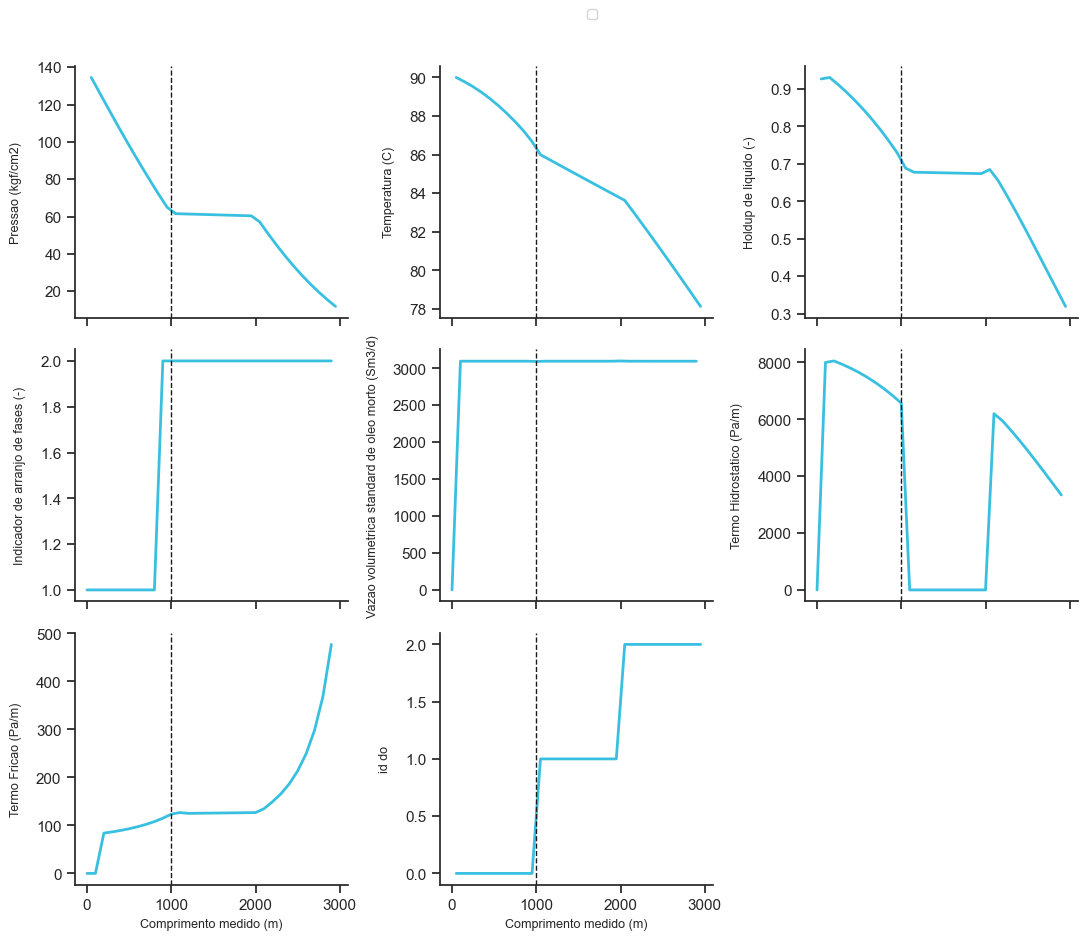

In [20]:
caso_base.plotar_perfis(indicar_anm=True);

In the profile graphs above, the dashed vertical line represents the position of the ANM. Observe the figure and analyze the behavior of each of the variables. Can you interpret the behavioral changes along the three sections (well, flowline, and riser), each with a length of 1000 meters?

### Obtaining TPR curves

The solution obtained above corresponds to the equilibrium flow rate of the IPR, at which the available pressure at the bottom of the well equals the pressure necessary to overcome the pressure loss and reach the separator with the pressure specified in BC2.

To generate a TPR curve, it is necessary to remove the boundary condition associated with the IPR (deactivating it through the `ativo` boolean) and add a new boundary condition that corresponds to the specified liquid flow rate at the inlet:

In [21]:
caso_base.ipr[0]['ativo'] = False

nova_cc_mon = {
    "id": 0,
    "indiFluidoPro": 0, #id do fluido definido anteriormente
    "comprimentoMedido": 0.1, #m
    "tempo": [0], #s
    "temperatura": [90] #degC
} 

caso_base.fonteLiquido = [nova_cc_mon]

Note that we did not define `vazaoLiquido` in the new boundary condition (BC). It will be added in the `for` loop below, being configured thirty times, with different values at each iteration. This will result in thirty simulations, each representing a different flow condition. For each flow rate, an associated pressure at the bottom of the well ($P_{wf}$) will be calculated. The combinations of $Q$ (flow rate) and $P_{wf}$ obtained constitute the points that form the TPR curve.

In [22]:
%%time

vazoes_eixo_x = np.linspace(10,8000,30)  #sm3/d
casos = []

# rodando uma simulação para cada vazão
for vazao in vazoes_eixo_x:
    casos.append(copy.deepcopy(caso_base))
    casos[-1].configuracaoInicial['saidaClassica'] = False
    casos[-1].fonteLiquido[0]['vazaoLiquido'] = [vazao]
    casos[-1].simular()

# obtendo as pressoes de fundo a partir dos resultados dos vários casos
pressoes_fundo_tpr = np.array([casos[i].resultados['perfilProducao'].iloc[:,2][0,0] for i in range(len(casos))])

# reativando a CC IPR para o caso base
caso_base.ipr[0]['ativo'] = True
caso_base.fonteLiquido[0]['ativo'] = False































CPU times: total: 562 ms
Wall time: 1min 5s


### Plotting IPR and TPR

Let's finally visualize the curves!

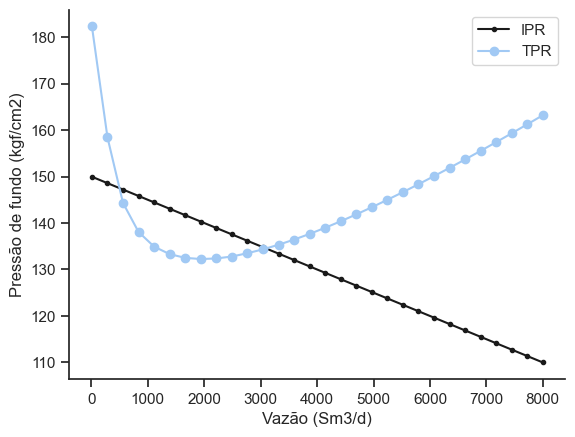

In [23]:
fig, ax = plt.subplots()

# função anônima representando a pressão do fundo do poço da IPR
Pwf_ipr = lambda Pe, Q, IP: Pe - Q/IP

# propriedades da IPR
Pe = caso_base.ipr[0]['pressaoEstatica'][0]
IP = caso_base.ipr[0]['ip'][0]

# calculando ipr!
pressoes_fundo_ipr = Pwf_ipr(Pe, vazoes_eixo_x, IP)

# plotando IPR
ax.plot(vazoes_eixo_x, pressoes_fundo_ipr, label='IPR', marker='.', c='k')

# plotando TPR
ax.plot(vazoes_eixo_x, pressoes_fundo_tpr, label=f'TPR', marker='o')

ax.set_xlabel('Vazão (Sm3/d)')
ax.set_ylabel('Pressão de fundo (kgf/cm2)');
ax.legend();

One of the intersection points between the curves represents the flow rate obtained in the base simulation, $Q = 3061$ sm$^3$/d, at which the IPR was used as a boundary condition (BC).

And what about the other intersection point? It corresponds to an unstable equilibrium point. This occurs when the TPR curve crosses the IPR from top to bottom. Naturally, simulators tend to converge to the stable solution, which acts as a numerical attractor of the system.

Finally, one last question about the figure: why is there a change in the direction of growth of the function in the TPR? Initially, bottom hole pressures decrease with increasing flow rate, but from a certain point onwards, they begin to increase. This behavior is related to the multiphase nature of the flow. At low flow rates, gas cannot efficiently entrain the liquid, which results in a significant increase in holdup and, consequently, in the hydrostatic term of pressure loss. As the flow rate increases, holdup decreases, reducing pressure loss until, at a certain point, the increase in pressure loss due to friction becomes predominant, causing pressure loss to increase again with increasing flow rate.

### Increasing production

Nodal analysis enables the evaluation of different flow scenarios based on available degrees of freedom, allowing the choice of the most appropriate production flow rate for the system. This activity is important for the design of new production systems.

In the following code, we repeat the analysis performed earlier, now considering different gas-oil ratio (GOR) values of the fluid:

In [24]:
%%time

caso_base.ipr[0]['ativo'] = False
caso_base.fonteLiquido[0]['ativo'] = True

RGO = [25,50,100,200,300] #sm3/sm3

vazoes_eixo_x = np.linspace(10,8000,30)  #sm3/d
pressoes_fundo_tpr = []

# rodando uma simulação para cada RGO e para cada vazão
for rgo in RGO:
    casos = []
    for vazao in vazoes_eixo_x:
        casos.append(copy.deepcopy(caso_base))
        casos[-1].configuracaoInicial['saidaClassica'] = False
        casos[-1].fluidosProducao[0]['rgo'] = rgo
        casos[-1].fonteLiquido[0]['vazaoLiquido'] = [vazao]
        casos[-1].simular()
    # obtendo as pressoes de fundo a partir dos resultados dos vários casos
    pressoes_fundo_tpr.append(np.array([casos[i].resultados['perfilProducao'].iloc[:,2][0,0] for i in range(len(casos))]))

caso_base.ipr[0]['ativo'] = True
caso_base.fonteLiquido[0]['ativo'] = False























































































































































CPU times: total: 3.5 s
Wall time: 5min 32s


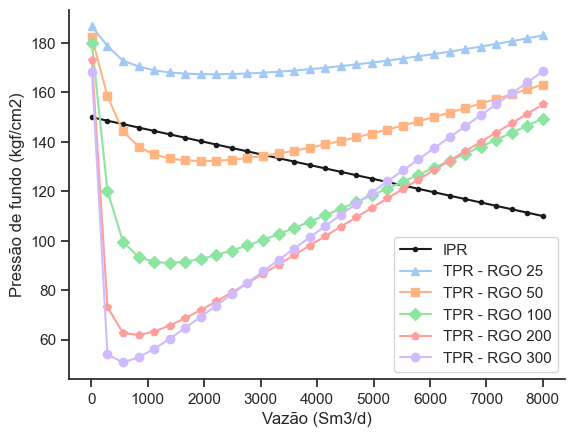

In [25]:
fig, ax = plt.subplots()

markers = ['^','s','D','p','o']

# plotando IPR
ax.plot(vazoes_eixo_x, pressoes_fundo_ipr, label='IPR', marker='.', c='k')

# plotando as várias TPR
for i in range(len(RGO)):
    ax.plot(vazoes_eixo_x, pressoes_fundo_tpr[i], label=f'TPR - RGO {RGO[i]}', marker=markers[i])

ax.set_xlabel('Vazão (Sm3/d)')
ax.set_ylabel('Pressão de fundo (kgf/cm2)');
ax.legend();

It is observed that, in the case of GOR equal to 25, the TPR curve does not intersect the IPR curve, which indicates that the reservoir is not capable of providing, at the bottom of the well, the pressure necessary to sustain any flow rate under this condition. In this way, the well is said to be non-flowing and therefore artificial lift methods must be used. On the other hand, for GOR equal to 100, the stable crossing point occurs at a significantly higher flow rate compared to the base case (GOR 50). This behavior can be attributed to the reduction in flow resistance, resulting from the lower average specific mass of the fluid, which reduces the hydrostatic term of pressure loss – the main factor in this scenario.

However, there is a limit to increasing GOR. As GOR increases, the friction term of pressure loss becomes progressively more relevant. Therefore, the productivity gain in equilibrium flow rate between the cases of GOR 100 and GOR 200 is significantly smaller compared to the increment observed between the cases of GOR 50 and GOR 100. In the case of GOR 300, a reversal is observed: the equilibrium flow rate is lower than that recorded in the case of GOR 100.

Even without considering the IPR curve, it is possible to notice that, at high flow rates, the curves tend to cross, resulting in a trend reversal. In this region, higher GORs can result in higher bottom hole pressures (and, consequently, higher pressure losses) for the same flow rate. This behavior contrasts with that observed in the low flow rate region, where the hydrostatic term exerts greater influence and high GORs result in lower pressure loss.

## Saving the base case

In the command below, we save the base case in a JSON to be able to import it in the next tutorial.

In [26]:
caso_base.to_json('caso_base1_tutoriais')

## Try it yourself!

**1**. Plot new sets of TPR curves like those in the last figure we obtained, varying other parameters such as line diameter, oil density, or water fraction.

**2**. Choose some simulations that make up the TPR curves (you can access them in the `casos` list) and visualize the profiles along the flow. Pay attention to the differences from the base case, especially at high flow rates. Compare, for example, the flow patterns and the relative magnitudes of the friction and hydrostatic terms of pressure loss.